# Financial Sentiment Analysis Pipeline using Fine-Tuned BERT

This notebook fine-tunes a bidirectional `bert-base-uncased` Transformer model on financial market text entries for binary sentiment classification (Positive vs. Negative).

In [3]:
# Install required libraries
!pip install -q transformers torch scikit-learn pandas matplotlib seaborn

import os
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# Set execution device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using execution device: {device}")

Using execution device: cuda


## 1. Data Filtering & Exploratory Data Analysis

We load `data.csv`, drop neutral statements to focus on strong directional sentiment signals, map text labels to binary targets, and visualize the dataset balance.

=== Dataset Summary ===
                 Metric  Value
      Total Raw Samples   5842
Filtered Binary Samples   2712
   Positive Class Count   1852
   Negative Class Count    860


/tmp/ipykernel_1245/304582858.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Sentiment', data=df_filtered, palette='Set2')


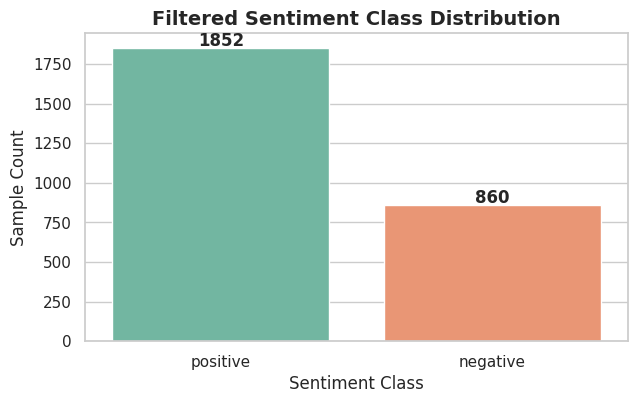

In [4]:
# 1. Load dataset
df = pd.read_csv("data.csv")

# 2. Filter out neutral entries
df_filtered = df[df['Sentiment'] != 'neutral'].copy()

# 3. Map binary labels: Positive = 1, Negative = 0
df_filtered['label'] = df_filtered['Sentiment'].map({'positive': 1, 'negative': 0})

# Display summary table
summary_df = pd.DataFrame({
    'Metric': ['Total Raw Samples', 'Filtered Binary Samples', 'Positive Class Count', 'Negative Class Count'],
    'Value': [len(df), len(df_filtered), (df_filtered['label'] == 1).sum(), (df_filtered['label'] == 0).sum()]
})
print("=== Dataset Summary ===")
print(summary_df.to_string(index=False))

# Visualization: Class Distribution
plt.figure(figsize=(7, 4))
sns.set_theme(style="whitegrid")
ax = sns.countplot(x='Sentiment', data=df_filtered, palette='Set2')
plt.title("Filtered Sentiment Class Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Sentiment Class", fontsize=12)
plt.ylabel("Sample Count", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.show()

# Extract arrays and perform Train/Val Split (85/15)
texts = df_filtered['Sentence'].values
labels = df_filtered['label'].values

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.15, random_state=42, stratify=labels
)

## 2. Tokenization & PyTorch Dataset Pipeline

We initialize the WordPiece tokenizer for `bert-base-uncased` and construct a custom PyTorch `Dataset` to generate input IDs and attention masks.

In [5]:
# Initialize BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Create DataLoaders
train_dataset = FinancialSentimentDataset(train_texts, train_labels, tokenizer)
val_dataset = FinancialSentimentDataset(val_texts, val_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## 3. Model Architecture & Fine-Tuning Execution

We load the pre-trained `BertForSequenceClassification` model, set up the `AdamW` optimizer, and run training across 3 epochs while tracking train and validation loss/accuracy.

In [6]:
# Initialize Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

epochs = 3
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Metric Tracking Lists
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting Fine-Tuning Loop...\n")
for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    total_train_loss, train_correct = 0, 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_b = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels_b)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = torch.argmax(outputs.logits, dim=1)
        train_correct += (preds == labels_b).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = train_correct / len(train_dataset)

    # --- Validation Phase ---
    model.eval()
    total_val_loss, val_correct = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_b = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels_b)
            total_val_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1)
            val_correct += (preds == labels_b).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = val_correct / len(val_dataset)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Fine-Tuning Loop...

Epoch 1/3 | Train Loss: 0.5337 | Train Acc: 70.59% | Val Loss: 0.2973 | Val Acc: 88.70%
Epoch 2/3 | Train Loss: 0.2189 | Train Acc: 91.71% | Val Loss: 0.2084 | Val Acc: 91.65%
Epoch 3/3 | Train Loss: 0.1339 | Train Acc: 95.57% | Val Loss: 0.2202 | Val Acc: 92.14%


## 4. Evaluation Dashboard: Curves, Heatmaps & Metrics

We generate loss/accuracy training trajectories, plot the Confusion Matrix heatmap, and output the detailed classification table.

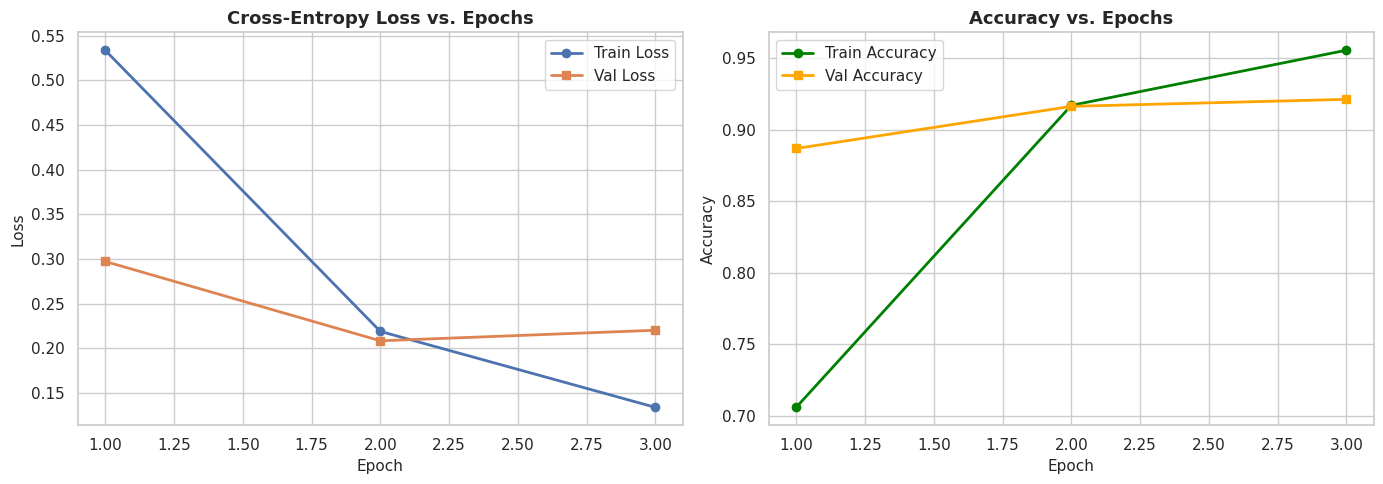

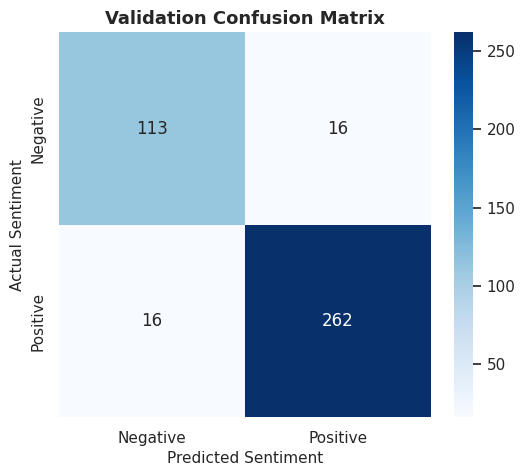


=== Classification Report ===
              precision  recall  f1-score   support
Negative (0)     0.8760  0.8760    0.8760  129.0000
Positive (1)     0.9424  0.9424    0.9424  278.0000
accuracy         0.9214  0.9214    0.9214    0.9214
macro avg        0.9092  0.9092    0.9092  407.0000
weighted avg     0.9214  0.9214    0.9214  407.0000


In [7]:
# 1. Training & Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, epochs+1), history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax1.plot(range(1, epochs+1), history['val_loss'], label='Val Loss', marker='s', linewidth=2)
ax1.set_title('Cross-Entropy Loss vs. Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.legend()

ax2.plot(range(1, epochs+1), history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, color='green')
ax2.plot(range(1, epochs+1), history['val_acc'], label='Val Accuracy', marker='s', linewidth=2, color='orange')
ax2.set_title('Accuracy vs. Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.legend()
plt.tight_layout()
plt.show()

# 2. Collect Full Validation Predictions
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(batch['labels'].numpy())

# Calculate Final Metrics
acc = accuracy_score(all_targets, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='binary')

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title("Validation Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Sentiment", fontsize=11)
plt.ylabel("Actual Sentiment", fontsize=11)
plt.show()

# 4. Detailed Classification Report Table
report_dict = classification_report(all_targets, all_preds, target_names=['Negative (0)', 'Positive (1)'], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(4)
print("\n=== Classification Report ===")
print(report_df)

## 5. Benchmarking Metrics Extraction

We measure single-sequence inference latency across 100 sample runs and calculate model footprint size on disk.

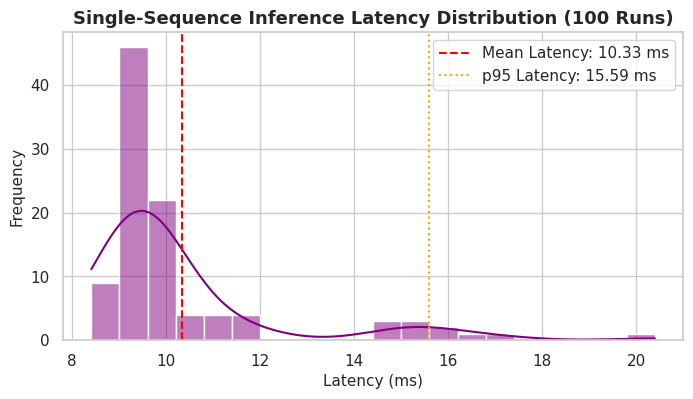

                METRICS CARD             
  Test Accuracy           : 92.14%
  Binary F1-Score         : 0.9424
  Precision               : 0.9424
  Recall                  : 0.9424
  Mean Inference Latency : 10.33 ms
  p95 Inference Latency  : 15.59 ms
  Model Footprint Size   : 417.73 MB


In [9]:
# 1. Save Model Weights
model_path = "pytorch_model.bin"
torch.save(model.state_dict(), model_path)
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

# 2. Latency Benchmarking (100 Runs)
test_sample = "Operating profit margins increased by 14% quarter-over-quarter due to strong regional demand."
inputs = tokenizer(test_sample, return_tensors='pt', truncation=True, padding='max_length', max_length=128).to(device)

model.eval()
latencies = []

# Warm-up run
with torch.no_grad():
    _ = model(**inputs)

# Measurement loop
with torch.no_grad():
    for _ in range(100):
        start = time.perf_counter()
        _ = model(**inputs)
        end = time.perf_counter()
        latencies.append((end - start) * 1000)

avg_latency = np.mean(latencies)
p95_latency = np.percentile(latencies, 95)

# Plot Latency Distribution
plt.figure(figsize=(8, 4))
sns.histplot(latencies, kde=True, color='purple', bins=20)
plt.axvline(avg_latency, color='red', linestyle='--', label=f'Mean Latency: {avg_latency:.2f} ms')
plt.axvline(p95_latency, color='orange', linestyle=':', label=f'p95 Latency: {p95_latency:.2f} ms')
plt.title("Single-Sequence Inference Latency Distribution (100 Runs)", fontsize=13, fontweight='bold')
plt.xlabel("Latency (ms)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.legend()
plt.show()

# Print Final SDE Metrics Card
print("="*50)
print("                METRICS CARD             ")
print("="*50)
print(f"  Test Accuracy           : {acc * 100:.2f}%")
print(f"  Binary F1-Score         : {f1:.4f}")
print(f"  Precision               : {precision:.4f}")
print(f"  Recall                  : {recall:.4f}")
print(f"  Mean Inference Latency : {avg_latency:.2f} ms")
print(f"  p95 Inference Latency  : {p95_latency:.2f} ms")
print(f"  Model Footprint Size   : {model_size_mb:.2f} MB")
print("="*50)